In [ ]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import esda
from libpysal import weights
from splot.esda import lisa_cluster

In [3]:
G = ox.load_graphml(
    "../data/processed/paris_simplified_results/paris_cleaned_multigraph.graphml"
)
gdf_edges = ox.graph_to_gdfs(G, edges=True, nodes=False)
gdf_edges = gdf_edges[["geometry", "length", "built"]]

In [4]:
gdf_iris = gpd.read_file(
    "../data/processed/paris_official_data/paris_dem_iris_condensed_enriched.gpkg"
)

In [5]:
gdf_iris = gdf_iris.to_crs(gdf_edges.crs)

In [10]:
BUSINESSES_TO_COUNT = [
    "Alimentaire",
    "Grand magasin",
    "Hôtel",
    "Non Alimentaire",
    "Restauration",
    "Service commercial",
]

In [92]:
gdf_iris.drop(
    ["CODE_IRIS", "geometry", "population", "active_population", "poverty_rate"]
    + BUSINESSES_TO_COUNT
    + [bus + "_density" for bus in BUSINESSES_TO_COUNT],
    axis=1,
).corr()

,pop_density,median_income,commuter_cyclist_share,commuter_driver_share,LUD_share,LUG_share
pop_density,1.000000,-0.280120,0.081091,-0.155952,-0.163286,0.348464
median_income,-0.280120,1.000000,0.009482,0.269896,0.536528,-0.457109
commuter_cyclist_share,0.081091,0.009482,1.000000,-0.263286,-0.210663,0.278606
commuter_driver_share,-0.155952,0.269896,-0.263286,1.000000,0.186023,-0.688710
LUD_share,-0.163286,0.536528,-0.210663,0.186023,1.000000,-0.299089
LUG_share,0.348464,-0.457109,0.278606,-0.688710,-0.299089,1.000000


In [89]:
gdf_vote_sta = gpd.read_file(
    "../data/processed/paris_official_data/paris_vote_list.gpkg"
)
gdf_vote_sta = gdf_vote_sta.to_crs(gdf_edges.crs)

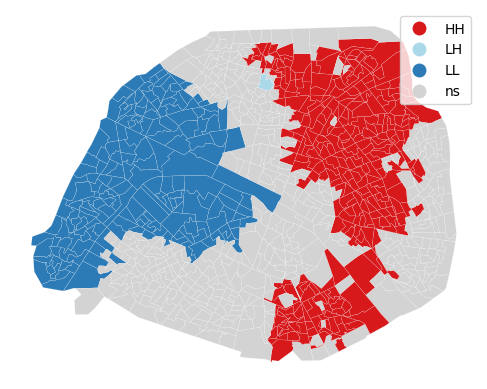

In [90]:
w = weights.Queen.from_dataframe(gdf_vote_sta, use_index=False)
w.transform = "R"
moran = esda.moran.Moran_Local(gdf_vote_sta["LUG_share"], w)
fig = lisa_cluster(moran, gdf_vote_sta)
plt.show()

In [91]:
share = {}
total = gdf_vote_sta["NB_EXPRIM"].sum()
for label in gdf_vote_sta.columns[:9]:
    share[label] = round(100 * (gdf_vote_sta[label].sum() / total), 1)
share

{'LDIV': np.float64(0.0),
 'LDVC': np.float64(1.7),
 'LDVD': np.float64(0.4),
 'LFI': np.float64(1.0),
 'LRN': np.float64(0.0),
 'LUC': np.float64(12.8),
 'LUD': np.float64(36.6),
 'LUG': np.float64(47.3),
 'LVEC': np.float64(0.1)}

In [93]:
gdf_vote_arr = gpd.read_file(
    "../data/processed/paris_simplified_results/paris_vote_arr_bikenet.gpkg"
)

In [108]:
rm = gdf_vote_arr["LUD_share"].mean()
lm = gdf_vote_arr["LUG_share"].mean()
vote_avg_ratio = rm - lm
gdf_vote_arr["ratio_lr"] = (
    (gdf_vote_arr["LUD"] - gdf_vote_arr["LUG"]) / gdf_vote_arr["NB_EXPRIM"]
) - vote_avg_ratio

In [110]:
vote_avg_ratio

np.float64(-0.06705370037347441)

<Axes: >

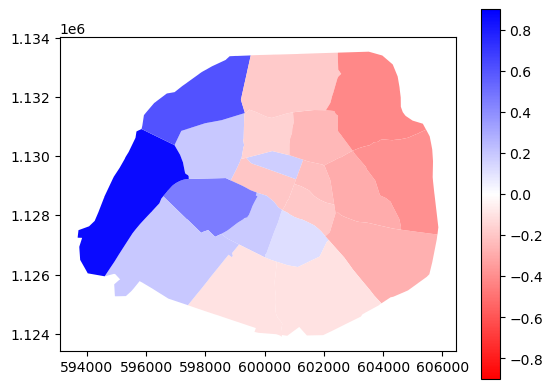

In [111]:
gdf_vote_arr.plot(column="ratio_lr", legend=True, cmap="bwr_r", vmin=-0.9, vmax=0.9)

(-0.4, 0.6)

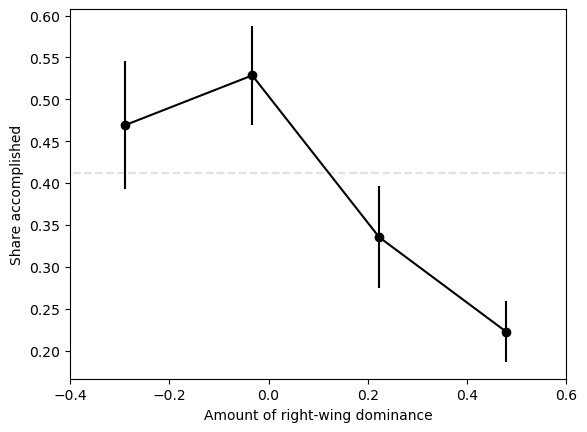

In [120]:
fig, ax = plt.subplots()
mean_acc = gdf_vote_arr["length_accomplished_share"].mean()
bin_edges = np.linspace(
    gdf_vote_arr["ratio_lr"].min(), gdf_vote_arr["ratio_lr"].max(), num=6
)
res = [
    gdf_vote_arr[
        (gdf_vote_arr["ratio_lr"] >= bin_edges[i])
        & (gdf_vote_arr["ratio_lr"] < bin_edges[i + 1])
    ]["length_accomplished_share"].mean()
    for i in range(len(bin_edges) - 1)
]
err = [
    gdf_vote_arr[
        (gdf_vote_arr["ratio_lr"] >= bin_edges[i])
        & (gdf_vote_arr["ratio_lr"] < bin_edges[i + 1])
    ]["length_accomplished_share"].sem()
    for i in range(len(bin_edges) - 1)
]
ax.errorbar(
    [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(len(bin_edges) - 1)],
    res,
    yerr=err,
    marker="o",
    color="black",
)
ax.plot(
    [bin_edges[0], bin_edges[-1]],
    [mean_acc, mean_acc],
    linestyle="dashed",
    color="#E1E1E1",
    zorder=0,
)
ax.set_ylabel("Share accomplished")
ax.set_xlabel("Amount of right-wing dominance")
ax.set_xlim([-0.4, 0.6])